# Mode A: Baseline Pure NSGA-II

**Self-contained experiment notebook using DRY architecture.**

## Architecture (DRY Principle)

| Location | What | Example |
|----------|------|---------|
| `src/notebooks/` | Reusable functions | `load_data()`, `run_nsga2()`, `plot_convergence()` |
| `configs/time_settings.py` | Global time config | `quantum_minutes`, `opening_time` |
| **This notebook** | Mode-specific config | `POP_SIZE`, `NGEN`, experiment execution |

## Mode A: Pure NSGA-II
- No repair heuristics
- No local search
- No RL guidance
- Baseline for comparison

## 1. Imports (from `src/notebooks/`)

In [ ]:
from __future__ import annotations
import random
import numpy as np
from pathlib import Path

# === DRY IMPORTS FROM src/notebooks/ ===
from src.notebooks.data_loader import load_data
from src.notebooks.population import create_random_individual
from src.notebooks.operators import course_aware_crossover, smart_mutation
from src.notebooks.evaluation import create_evaluator, get_constraint_breakdown
from src.notebooks.evolution import run_nsga2, EvolutionConfig, get_best_individual
from src.notebooks.visualization import plot_convergence, plot_constraint_breakdown, print_summary

print(" All imports from src/notebooks/ successful!")

✅ All imports from src/notebooks/ successful!


## 2. Mode A Configuration (Inline - Mode-Specific)

In [ ]:
# ============================================================================
# MODE A CONFIGURATION - Modify these as needed
# ============================================================================

SEED = 42
random.seed(SEED)
np.random.seed(SEED)

# Evolution config (inline - mode-specific)
config = EvolutionConfig(
    pop_size=50,
    ngen=100,
    cxpb=0.9,
    mutpb=0.2,
    fitness_weights=(-1.0, -0.01),  # (hard, soft) - both minimized
    verbose=True,
    log_interval=20,
)

# Paths
DATA_DIR = Path("../data")
OUTPUT_DIR = Path("../output/notebooks")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

print(f" Mode A Config: pop={config.pop_size}, ngen={config.ngen}, cxpb={config.cxpb}")

✅ Mode A Config: pop=50, ngen=100, cxpb=0.9


## 3. Load Data (using `src/notebooks/data_loader`)

In [ ]:
# Load all data with single function call
data = load_data(
    data_dir=DATA_DIR,
    opening_time="10:00",
    closing_time="17:00",
    closed_days=["Saturday"],
)

print(f" {data.summary()}")

[!warn] groups enrolled but courses missing

CE604: BCE5A, BCE5B, BCE5C, BCE5D, BCE5E, BCE5F (ltp null)

ENCE 256: BCE4A, BCE4B, BCE4C, BCE4D, BCE4E, BCE4F (ltp null)

ENIE 254: BIE4A, BIE4B (ltp null)

ME706: BME7A, BME7B (ltp null)

16 course enrollments skipped

✅ Courses: 668, Instructors: 181, Rooms: 67, Groups: 74, Pairs: 527, Quanta: 42


## 4. Test Population & Evaluation

In [ ]:
# Test individual creation
test_ind = create_random_individual(data)
print(f" Individual has {len(test_ind)} genes")

# Test evaluation
evaluate = create_evaluator(data)
test_fitness = evaluate(test_ind)
print(f" Test fitness: hard={test_fitness[0]}, soft={test_fitness[1]}")

✅ Individual has 713 genes
✅ Test fitness: hard=1248, soft=0


## 5. Run NSGA-II Evolution

In [20]:
# Run evolution with DRY components
final_pop, stats = run_nsga2(
    data=data,
    config=config,
    create_individual_fn=create_random_individual,
    evaluate_fn=evaluate,
    crossover_fn=course_aware_crossover,
    mutate_fn=lambda ind: smart_mutation(ind, data),  # Closure over data
)

🧬 NSGA-II: pop=50, ngen=100
  Gen   0: min_hard=1238, feasible=0/50
  Gen   0: min_hard=1238, feasible=0/50
  Gen  20: min_hard=1055, feasible=0/50
  Gen  20: min_hard=1055, feasible=0/50
  Gen  40: min_hard=929, feasible=0/50
  Gen  40: min_hard=929, feasible=0/50
  Gen  60: min_hard=883, feasible=0/50
  Gen  60: min_hard=883, feasible=0/50
  Gen  80: min_hard=880, feasible=0/50
  Gen  80: min_hard=880, feasible=0/50
  Gen  99: min_hard=880, feasible=0/50
✅ Done in 60.6s
  Gen  99: min_hard=880, feasible=0/50
✅ Done in 60.6s


## 6. Results & Visualization


📊 RESULTS SUMMARY
Best Solution: hard=880.0, soft=0.0
Final Generation: min_hard=880, avg=880.0
Feasible Solutions: 0
Elapsed Time: 60.6s

Constraint Breakdown:
  student_group_exclusivity: 529
  instructor_exclusivity: 84
  instructor_qualifications: 0
  room_exclusivity: 267
  room_suitability: 0
📊 Saved: ..\output\notebooks\mode_a_convergence.png


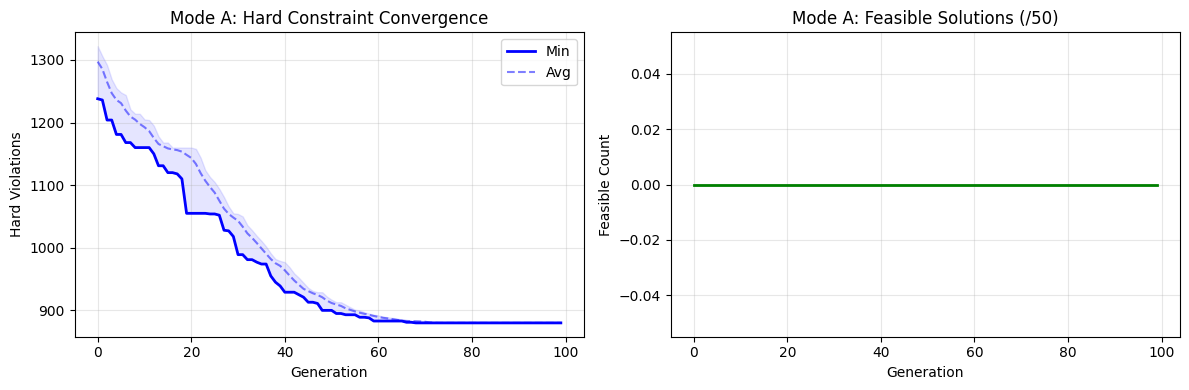

📊 Saved: ..\output\notebooks\mode_a_breakdown.png


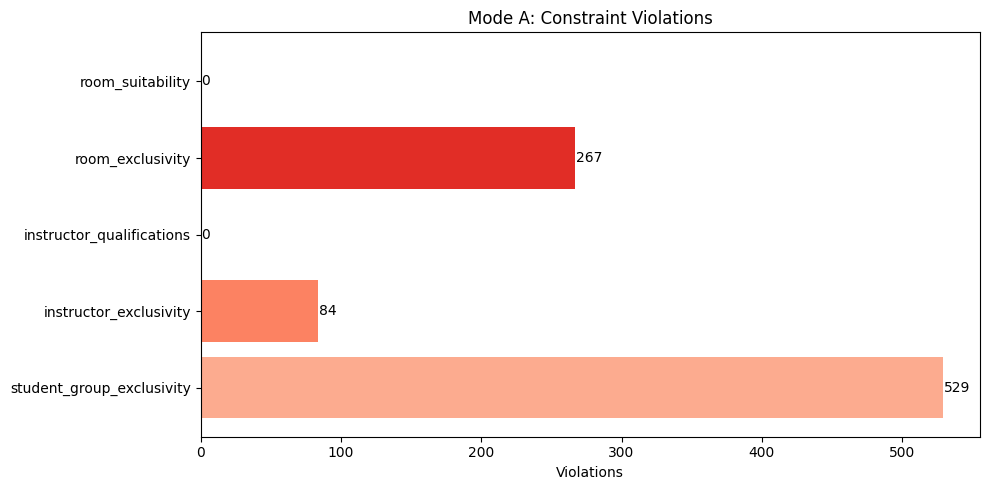

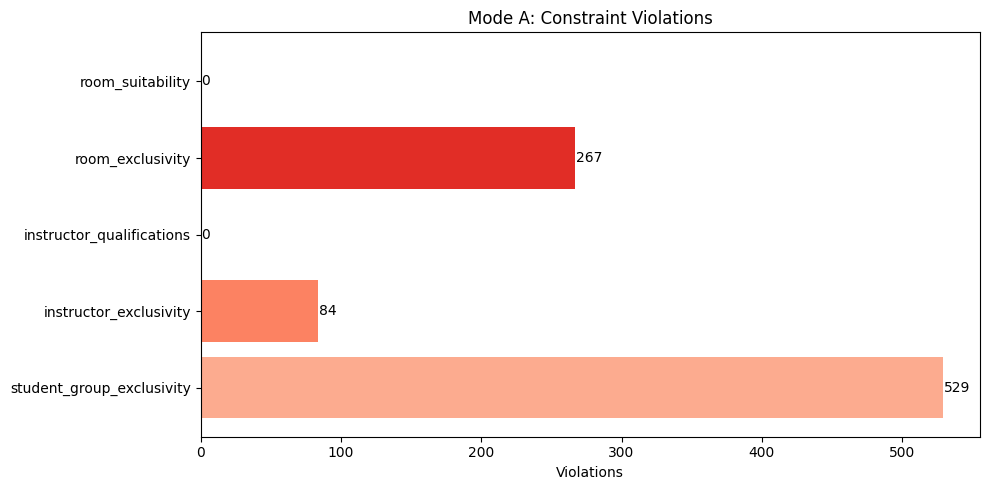

In [21]:
# Get best solution
best = get_best_individual(final_pop)
breakdown = get_constraint_breakdown(best, data)

# Print summary
print_summary(final_pop, stats, breakdown)

# Plot results
plot_convergence(stats, OUTPUT_DIR / "mode_a_convergence.png", title_prefix="Mode A: ")
plot_constraint_breakdown(breakdown, OUTPUT_DIR / "mode_a_breakdown.png", title="Mode A: Constraint Violations")

## 7. Full Production Export (Optional)

Run this cell to generate the same outputs as CLI production runs:
- `schedule.json` - Full decoded schedule
- `calendar.pdf` - Visual calendar
- `plots/constraints/` - Constraint trend plots
- `plots/nsga/` - NSGA metrics plots
- `csv/` - Evolution data CSVs

In [43]:
# Reload export module with fixed inline decode
import importlib
import src.notebooks.export
importlib.reload(src.notebooks.export)

from src.notebooks.export import export_full_results

# Generate all production outputs (same as CLI)
export_paths = export_full_results(
    population=final_pop,
    stats=stats,
    data=data,
    output_dir=OUTPUT_DIR,
    mode_name="mode_a_baseline",
)

# Show output location
print(f"\n📁 All files saved to: {export_paths['output_dir']}")

📦 Exporting full results for mode_a_baseline...
  [+] Exporting schedule and calendar...
 PDF saved as '..\output\notebooks\mode_a_baseline_20260120_112438\calendar.pdf'
[OK-KRISHNA] Schedule exported successfully!
[...]JSON: ..\output\notebooks\mode_a_baseline_20260120_112438\schedule.json
[...]PDF:  ..\output\notebooks\mode_a_baseline_20260120_112438\calendar.pdf
      ✓ schedule.json
      ✓ calendar.pdf
  [+] Exporting CSV data...
      ✓ metrics.csv
      ✓ pareto.csv
      ✓ fitness.csv
  [+] Generating constraint plots...
      ✓ 3 constraint plots
  [+] Generating NSGA plots...
      ✓ 2 NSGA plots

✅ Full export complete: ..\output\notebooks\mode_a_baseline_20260120_112438
   📁 notebooks\mode_a_baseline_20260120_112438

📁 All files saved to: ..\output\notebooks\mode_a_baseline_20260120_112438
